In [3]:
#IRIS
#IMPORTING REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [4]:

#PART1
#Loading the csv data into a pandas dataframe
iris_data = pd.read_csv(r"C:\Users\USER\Desktop\TLK\Iris.csv")

In [5]:
iris_data.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [6]:
iris_data.shape

(150, 6)

In [7]:
iris_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [8]:
#Check for missing value
iris_data.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [9]:
#Check for duplicates
iris_data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool

In [10]:
iris_data.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [11]:
#Data preprocessing

In [12]:
#Missing value treatment
#None since dataset has no mising values

In [13]:
#PART C outlier detection and treatment

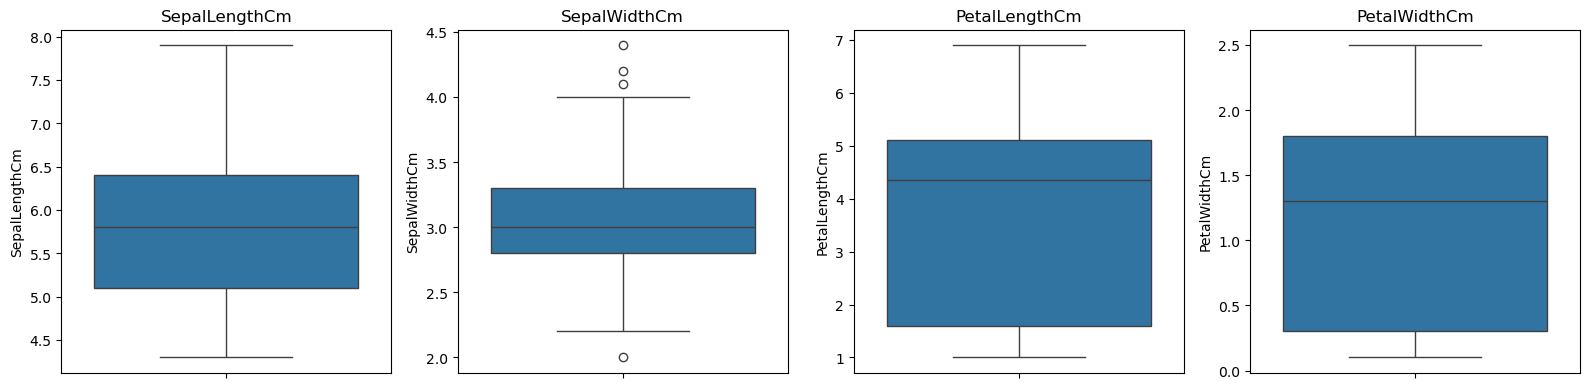

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

for i, col in enumerate(features):
    sns.boxplot(y=iris_data[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [15]:
Q1 = iris_data['SepalWidthCm'].quantile(0.25)
Q3 = iris_data['SepalWidthCm'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = iris_data[(iris_data['SepalWidthCm'] < lower_bound) | (iris_data['SepalWidthCm'] > upper_bound)]
print(f"Number of outliers in SepalWidthCm: {len(outliers)}")

Number of outliers in SepalWidthCm: 4


In [16]:
Q1 = iris_data['SepalWidthCm'].quantile(0.25)
Q3 = iris_data['SepalWidthCm'].quantile(0.75)
Q1,Q3

(np.float64(2.8), np.float64(3.3))

In [17]:
IQR = Q3 - Q1
IQR

np.float64(0.5)

In [18]:
iris_data['SepalWidthCm'][(iris_data['SepalWidthCm'] < lower_bound) | (iris_data['SepalWidthCm'] > upper_bound)]

15    4.4
32    4.1
33    4.2
60    2.0
Name: SepalWidthCm, dtype: float64

In [19]:
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
lower_limit, upper_limit

(np.float64(2.05), np.float64(4.05))

In [20]:
#CAP/REPLACEMENT METHOD
iris_data['SepalWidthCm'] = iris_data['SepalWidthCm'].clip(lower_limit, upper_limit)

In [21]:
iris_data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [22]:
#Categorical Encodiing

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
iris_data['Species'] = le.fit_transform(iris_data['Species'])

In [24]:
iris_data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [25]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


In [26]:
iris_data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [27]:
#Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
iris_data[features] = scaler.fit_transform(iris_data[features])

In [28]:
#PART 3
#EXPLORATORY DATA ANALYSIS

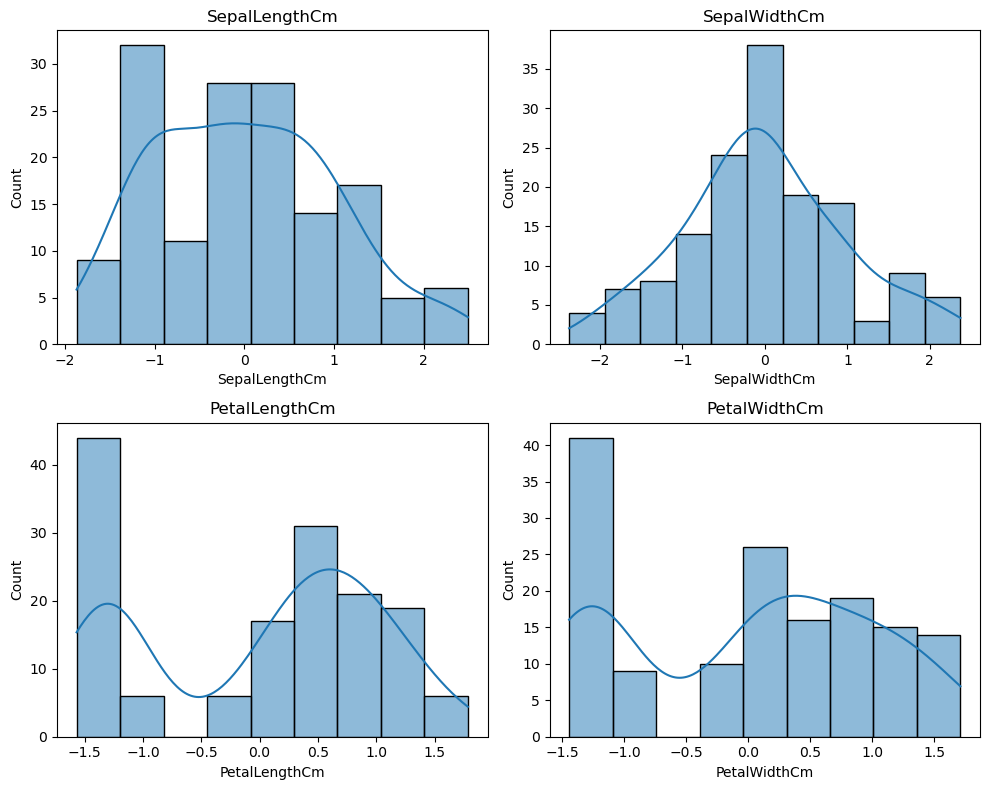

In [29]:
#UNIVARIATE ANALYSIS
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, col in enumerate(features):
    sns.histplot(iris_data[col], kde=True, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(col)
plt.tight_layout()
plt.show()

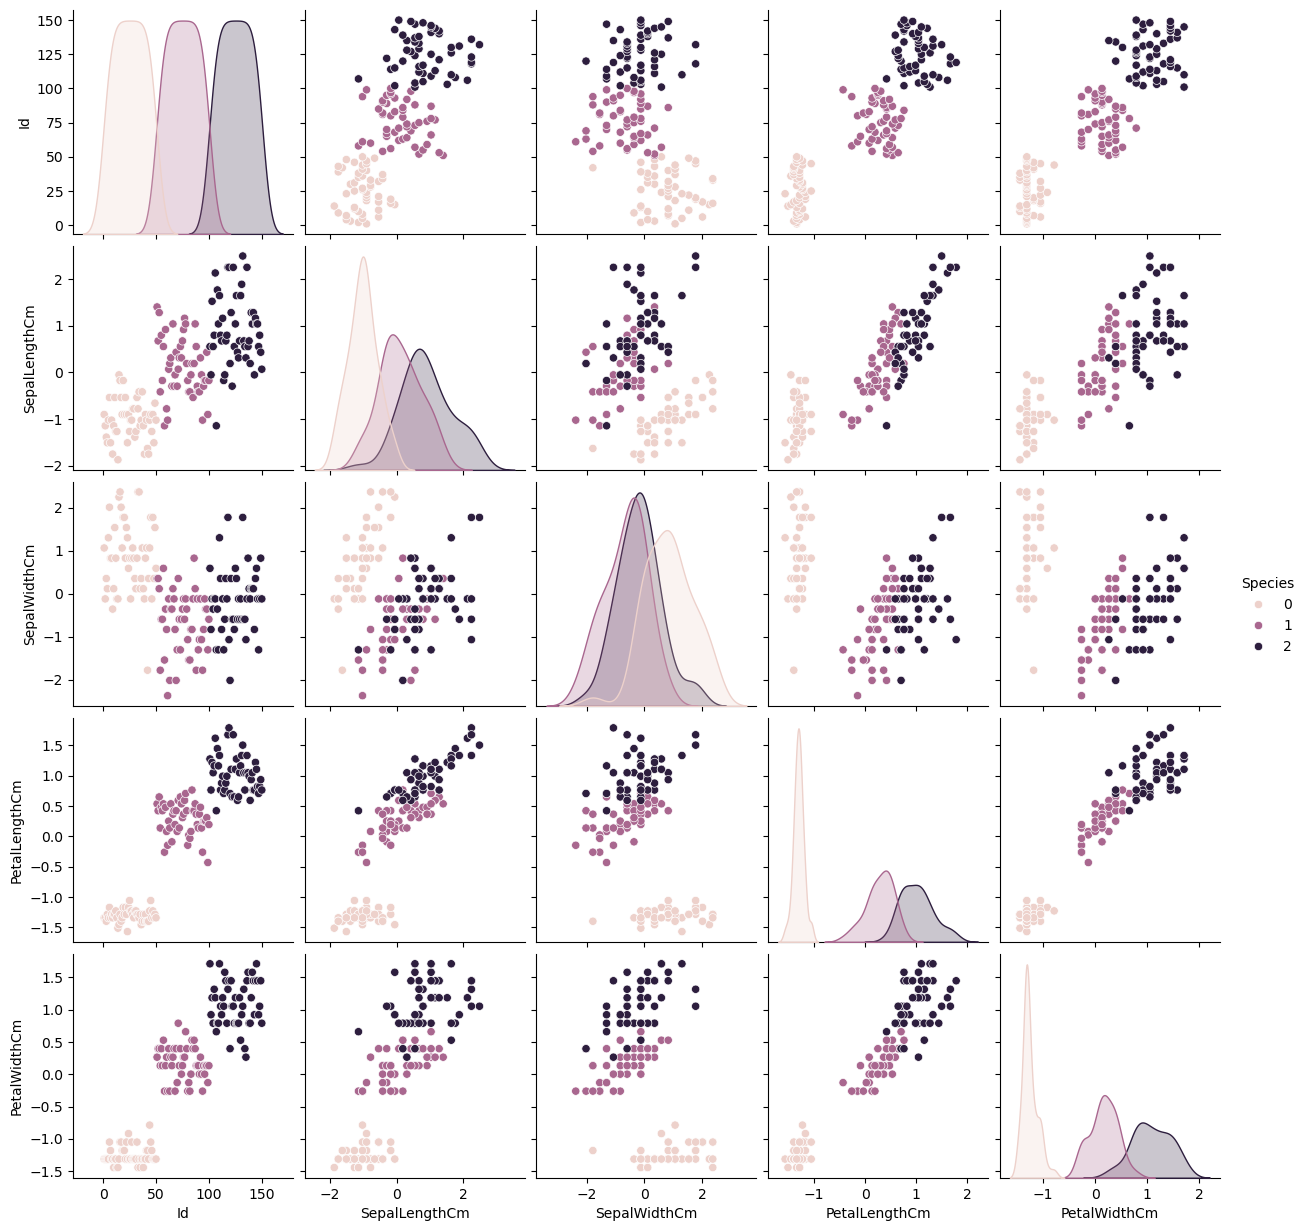

In [30]:
sns.pairplot(iris_data, hue='Species')
plt.show()

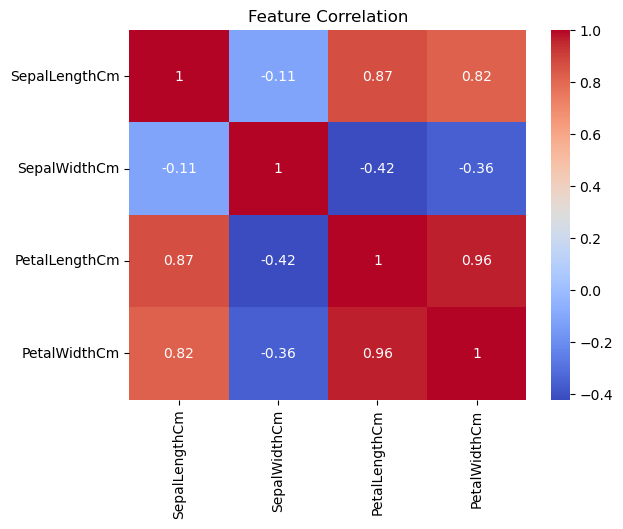

In [31]:
corr = iris_data[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

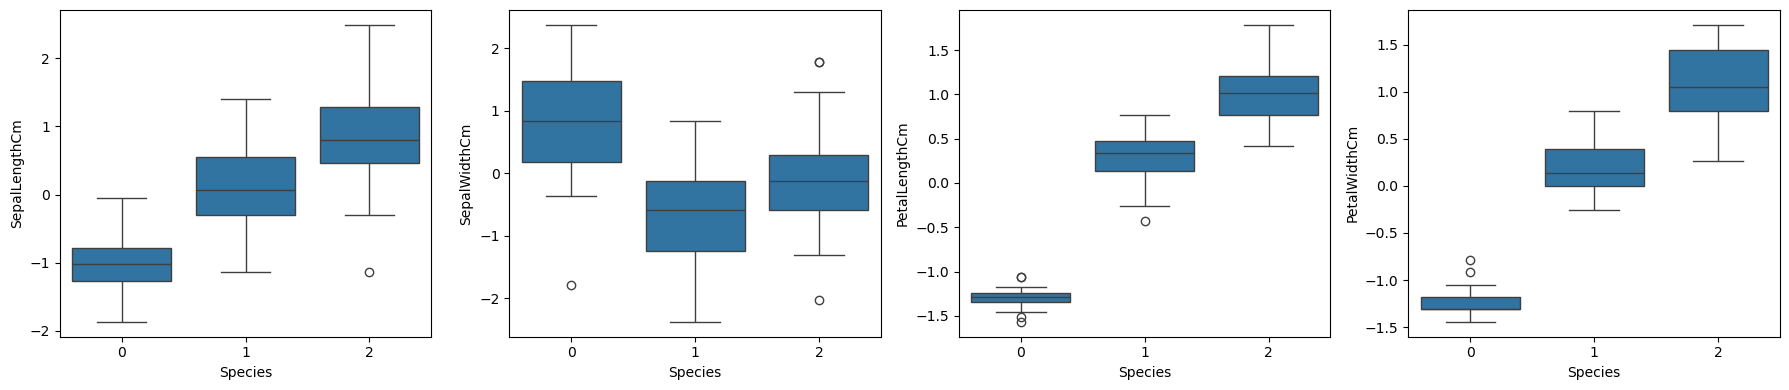

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(features):
    sns.boxplot(x='Species', y=col, data=iris_data, ax=axes[i])
plt.tight_layout()
plt.show()

In [33]:
iris_data.to_csv('IRIS_CLEANED.csv', index=False)

In [34]:
import os
print(os.getcwd())

C:\Users\USER


In [35]:
os.chdir(r'C:\Users\USER\Desktop\TLK\Ayomide Bello AnalystLab Africa Week1&2')

In [36]:
##WEEK 3
X = iris_data.drop(columns = ['Species'])
y = iris_data['Species']

In [37]:
X.head(), y.head()

(   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
 0   1      -0.900681      1.065722      -1.341272     -1.312977
 1   2      -1.143017     -0.120170      -1.341272     -1.312977
 2   3      -1.385353      0.354187      -1.398138     -1.312977
 3   4      -1.506521      0.117008      -1.284407     -1.312977
 4   5      -1.021849      1.302901      -1.341272     -1.312977,
 0    0
 1    0
 2    0
 3    0
 4    0
 Name: Species, dtype: int64)

In [38]:
#Build Ml Model
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [39]:
#MODEL TRAINING - LOGISTIC REGRESSION

In [40]:
model = LogisticRegression()

In [41]:
#training the logistic regression model with training data
model.fit(X_train, y_train)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [42]:
y_pred = model.predict(X_test)

[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


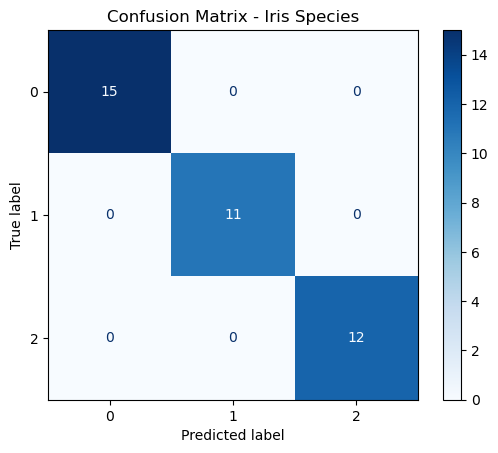

In [45]:
#Confusion matrix
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay


# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visual version
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Iris Species')
plt.show()

In [44]:
print('Accuracy on test data: ',accuracy_score(y_pred, y_test))

Accuracy on test data:  1.0


In [48]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

